In [1]:
import ast
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dill
from configs.data_constants_config import ALPHA

import mlflow
import mlflow.sklearn
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:
#Data loading
path = '/home/isha/Desktop/Projects/03_Remaining_Useful_Life_Prediction/artifacts/'
X_train = pd.read_csv(os.path.join(path, 'X_train_proper.csv'))
y_train = pd.read_csv(os.path.join(path, 'y_train_proper.csv')).values.ravel()
X_cal = pd.read_csv(os.path.join(path, 'X_cal.csv'))
y_cal = pd.read_csv(os.path.join(path, 'y_cal.csv')).values.ravel()
X_test = pd.read_csv(os.path.join(path, 'X_test_processed.csv'))
y_test = pd.read_csv(os.path.join(path, 'y_test.csv')).values.ravel()

#Top 5 models after hyperparameter tuning
top_df = pd.read_csv(os.path.join(path, 'top2_gp_models.csv'))

print('Top model (ranked by RMSE - MAE - R square):')
display(top_df[['model','test_rmse','test_mae','test_r2','best_params']])

Top model (ranked by RMSE - MAE - R square):


,model,test_rmse,test_mae,test_r2,best_params
0,Gaussian Process,17.562538,12.220109,0.807928,"{'alpha': 0.5, 'kernel': Matern(length_scale=1..."


In [3]:
X_train.shape, X_test.shape

((16778, 10), (100, 10))

In [4]:
X_train_gp = X_train.copy()
y_train_gp = y_train.copy()

X_test_gp = X_test.copy()
y_test_gp = y_test.copy()


#Downsampling method 1 - Discarded because it gives poor coverage, overconfident predictions and does not capture aleatoric uncertainty of sesnor data
if len(X_train_gp) > 2500:
    step = 5
    X_train_gp = X_train_gp.iloc[::step].reset_index(drop=True)
    y_train_gp = y_train_gp[::step]

if len(X_test_gp) > 1000:
    step = 5
    X_test_gp = X_test_gp.iloc[::step].reset_index(drop=True)
    y_test_gp = y_test_gp[::step]
    
'''
#Downsampling method 2 - Random sampling to reduce training size to 2500 samples
X_train_gp = X_train.sample(n=2500, random_state=42)
y_train_gp = y_train[X_train_gp.index]



#Downsampling method 3 - Using landmark selection to reduce training size to 2500 samples
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2500, random_state=42)
cluster_labels = kmeans.fit_predict(X_train)
X_train_gp = pd.DataFrame(kmeans.cluster_centers_,columns=X_train.columns)
y_train_gp = np.array([y_train[cluster_labels == i].mean()for i in range(2500)])

print("Training samples:", len(X_train))
print("Unique samples:", len(np.unique(X_train, axis=0)))
print("Requested clusters:", 2500)
print("Clusters actually used:", len(np.unique(cluster_labels)))

'''

'\n#Downsampling method 2 - Random sampling to reduce training size to 2500 samples\nX_train_gp = X_train.sample(n=2500, random_state=42)\ny_train_gp = y_train[X_train_gp.index]\n\n\n\n#Downsampling method 3 - Using landmark selection to reduce training size to 2500 samples\nfrom sklearn.cluster import KMeans\n\nkmeans = KMeans(n_clusters=2500, random_state=42)\ncluster_labels = kmeans.fit_predict(X_train)\nX_train_gp = pd.DataFrame(kmeans.cluster_centers_,columns=X_train.columns)\ny_train_gp = np.array([y_train[cluster_labels == i].mean()for i in range(2500)])\n\nprint("Training samples:", len(X_train))\nprint("Unique samples:", len(np.unique(X_train, axis=0)))\nprint("Requested clusters:", 2500)\nprint("Clusters actually used:", len(np.unique(cluster_labels)))\n\n'

In [5]:
print(f"Training on {len(X_train_gp)} samples")
print(f"Testing  on {len(X_test_gp)} samples")

Training on 3356 samples
Testing  on 100 samples


# Using the best model
The best model is chosen where coverage is > 90%,the average prediction width is low and the RMSE error is least. 
This corresponds to GP with the following hyperparameters:
1. $\alpha =$ 0.01
2. Length scale $l =$ 0.5
3. $\nu =$ 2.5

In [6]:
l = [0.5]*10
kernel = (ConstantKernel(constant_value = 100.0) 
                            * Matern(length_scale = l, nu = 2.5) # length_scale_bounds=(1e-2, 1e3))
                            + WhiteKernel(noise_level = 1.0, noise_level_bounds = (1e-3, 1e3)))

                
                
gp_model = GaussianProcessRegressor(
                    kernel = kernel,
                    alpha = 0.01, 
                    n_restarts_optimizer = 5,
                    normalize_y = True,
                    random_state = 42 
                )


In [7]:
gp_model.fit(X_train_gp, y_train_gp)

,kernel,10**2 * Mater...noise_level=1)
,alpha,0.01
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,5
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,42
,kernel__k1,"10**2 * Mater... 0.5], nu=2.5)"
,kernel__k2,WhiteKernel(noise_level=1)
,kernel__k1__k1,10**2


## Plot 1: Point predictions + intervals 

In [8]:
from scipy.stats import norm

z = 1.96
y_pred, y_std = gp_model.predict(X_test_gp, return_std = True)

# 90% predictive interval
lower = y_pred - z * y_std
upper = y_pred + z * y_std

coverage = np.mean((y_test_gp >= lower) & (y_test_gp <= upper))*100
avg_width = np.mean(upper - lower)

print(f"Empirical coverage: {coverage:.3f}")
print(f"Average width: {avg_width:.3f}")

Empirical coverage: 92.000
Average width: 68.382


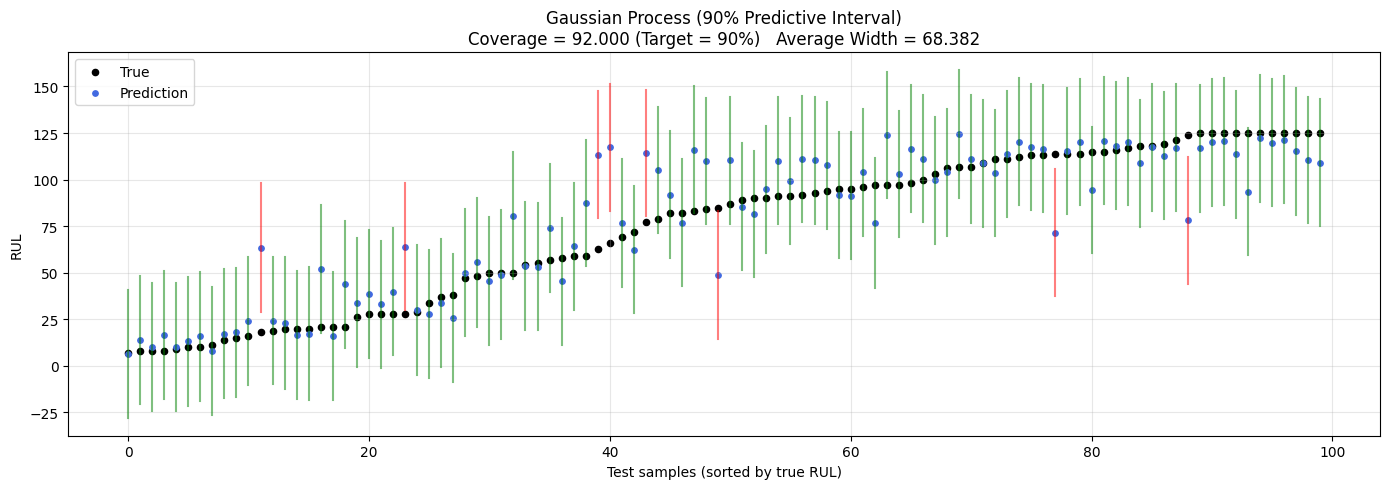

In [9]:
MAX_POINTS = 80

sort_idx = np.argsort(y_test_gp)
step = max(1, len(y_test_gp) // MAX_POINTS)

idx = sort_idx[::step]

y_true = y_test_gp[idx]
y_hat = y_pred[idx]

lo = lower[idx]
hi = upper[idx]

covered = (y_true >= lo) & (y_true <= hi)

x_pos = np.arange(len(idx))

fig, ax = plt.subplots(figsize=(14, 5))

for xi, l, h, cov in zip(x_pos, lo, hi, covered):

    ax.plot(
        [xi, xi],
        [l, h],
        color='green' if cov else 'red',
        linewidth=1.5,
        alpha=0.5
    )

ax.scatter(
    x_pos,
    y_true,
    color='black',
    s=20,
    label='True'
)

ax.scatter(
    x_pos,
    y_hat,
    color='royalblue',
    s=15,
    label='Prediction'
)

ax.set_xlabel("Test samples (sorted by true RUL)")
ax.set_ylabel("RUL")

ax.set_title(
    f"Gaussian Process (90% Predictive Interval)\n"
    f"Coverage = {coverage:.3f} (Target = 90%)   "
    f"Average Width = {avg_width:.3f}"
)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(path, "gp_prediction_intervals.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

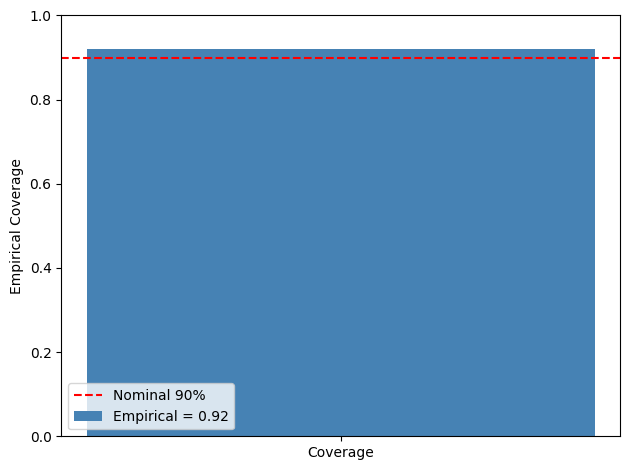

In [10]:
NOMINAL = (1 - ALPHA)

plt.axhline(NOMINAL, color="red", linestyle="--", label="Nominal 90%")
plt.bar([0], [coverage / 100], width=0.5, color="steelblue", label=rf"Empirical = {coverage/100}")

plt.xticks([0], ["Coverage"])
plt.ylabel("Empirical Coverage")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(path, "gp_empirical_coverage.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
summary = pd.DataFrame({
    "Model": ["Gaussian Process"],
    "Coverage": [coverage],
    'Prediction': np.mean(y_pred),
    "Average Interval Width": [avg_width]
})
display(summary)


,Model,Coverage,Prediction,Average Interval Width
0,Gaussian Process,92.0,78.345725,68.382465


In [15]:
# Generate predictions for the test set
y_pred, y_std = gp_model.predict(X_test_gp, return_std=True)

# Example: To get the exact Gaussian distribution parameters for the 1st sample in your test set:
sample_index = 0
mu_sample = y_pred[sample_index]
sigma_sample = y_std[sample_index]

print(f"Predictive Distribution for Test Sample {sample_index}:")
print(f"Mean = {mu_sample:.4f} cycles")
print(f"Standard Deviation = {sigma_sample:.4f} cycles")

Predictive Distribution for Test Sample 0:
Mean = 120.2973 cycles
Standard Deviation = 17.3616 cycles


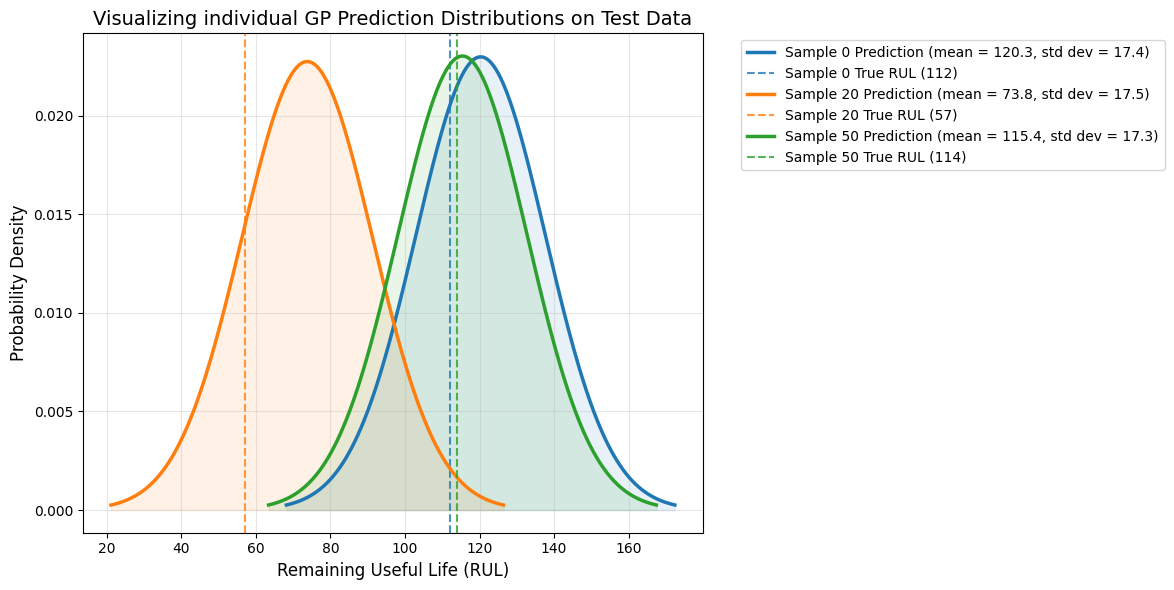

In [ ]:
from scipy.stats import norm

# Select three distinct test samples to visualize (e.g., sample 0, 20, and 50)
selected_samples = [0, 20, 50]

plt.figure(figsize=(12, 6))

for idx in selected_samples:
    mu = y_pred[idx]
    sigma = y_std[idx]
    true_val = y_test_gp[idx]
    
    # Generate an X axis range around this specific prediction's mean
    x = np.linspace(mu - 3*sigma, mu + 3*sigma, 500)
    y = norm.pdf(x, mu, sigma)
    
    # Plot the predictive Gaussian curve
    line = plt.plot(x, y, linewidth=2.5, 
                    label=f"Sample {idx} Prediction (mean = {mu:.1f}, std dev = {sigma:.1f})")
    color = line[0].get_color()
    plt.fill_between(x, y, alpha=0.1, color=color)
    
    # Draw a vertical line showing where the actual ground truth RUL is
    plt.axvline(true_val, color=color, linestyle="--", alpha=0.8, 
                label=f"Sample {idx} True RUL ({true_val})")

plt.title("Visualizing individual GP Prediction Distributions on Test Data", fontsize=14)
plt.xlabel("Remaining Useful Life (RUL)", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()

plt.show()

TypeError: only integer scalar arrays can be converted to a scalar index

# Extra